In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# df_capped120_q1   = pd.read_csv("../tables/pubmed_central_20260309_183439.tsv", sep="\t")
# df_capped200_q1   = pd.read_csv("../tables/pubmed_central_20260309_184017.tsv", sep="\t")
# df_uncapped_q1 = pd.read_csv("../tables/pubmed_central_20260309_182908.tsv", sep="\t")
# df_capped120_q2   = pd.read_csv("../tables/pubmed_central_20260309_180315.tsv", sep="\t")
# df_capped200_q2   = pd.read_csv("../tables/pubmed_central_20260309_185606.tsv", sep="\t")
# df_uncapped_q2 = pd.read_csv("../tables/pubmed_central_20260309_181417.tsv", sep="\t")

df_capped150_q1   = pd.read_csv("../tables/pubmed_central_20260312_093311.tsv", sep="\t")
df_capped150_q2   = pd.read_csv("../tables/pubmed_central_20260312_094127.tsv", sep="\t")
df_capped150_q3  = pd.read_csv("../tables/pubmed_central_20260312_111548.tsv", sep="\t")

In [3]:
import sys, os, textwrap
from collections import Counter
sys.path.insert(0, "../scrapers")
from scrape_publications import build_search_query, build_search_query_v2, build_search_query_v3

datasets = {
    "Q1 Capped 150": df_capped150_q1,
    "Q2 Capped 150": df_capped150_q2,
    "Q3 Capped 150": df_capped150_q3,
}

# ── Metrics ───────────────────────────────────────────────────────────────────
metrics = {}
for label, df in datasets.items():
    counts = df["Abbreviation"].value_counts()
    # Top 5 authors
    all_authors = []
    if "Authors" in df.columns:
        for authors in df["Authors"].dropna():
            all_authors.extend([a.strip() for a in str(authors).split(";")])
    top5_authors = Counter(all_authors).most_common(5)
    metrics[label] = {
        "Total records":          len(df),
        "Unique studies w/ hits": len(counts),
        "Max per study":          int(counts.max()),
        "Median per study":       round(float(counts.median()), 1),
        "top10":                  [f"{s} ({c})" for s, c in counts.head(10).items()],
        "top5_authors":           [f"{a} ({c})" for a, c in top5_authors],
    }

# ── Query examples ────────────────────────────────────────────────────────────
sample = df_capped150_q1.iloc[0]
q1_example = build_search_query(
    sample["Study Name"], sample["Abbreviation"],
    sample.get("Diseases Included", ""), sample.get("Coarse Data Modality", ""))
q2_example = build_search_query_v2(
    sample["Study Name"], sample["Abbreviation"],
    sample.get("Diseases Included", ""), sample.get("Coarse Data Modality", ""))
q3_example = build_search_query_v3(
    sample["Study Name"], sample["Abbreviation"],
    sample.get("Diseases Included", ""), sample.get("Coarse Data Modality", ""))

# ── Layout constants ──────────────────────────────────────────────────────────
col_w  = 22
lbl_w  = 30
labels = list(metrics.keys())
q1_labels = [l for l in labels if l.startswith("Q1")]
q2_labels = [l for l in labels if l.startswith("Q2")]
q3_labels = [l for l in labels if l.startswith("Q3")]
q1_span = len(q1_labels) * (col_w + 2)
q2_span = len(q2_labels) * (col_w + 2)
q3_span = len(q3_labels) * (col_w + 2)
total_w = lbl_w + q1_span + q2_span + q3_span

def hline(): print("-" * total_w)

def span_row(label, q1_text, q2_text, q3_text):
    """Print a row with text wrapping within each group's span."""
    q1_lines = textwrap.wrap(q1_text, width=q1_span - 1) or [""]
    q2_lines = textwrap.wrap(q2_text, width=q2_span - 1) or [""]
    q3_lines = textwrap.wrap(q3_text, width=q3_span - 1) or [""]
    for i in range(max(len(q1_lines), len(q2_lines), len(q3_lines))):
        lbl    = label if i == 0 else ""
        q1_str = (q1_lines[i] if i < len(q1_lines) else "").ljust(q1_span)
        q2_str = (q2_lines[i] if i < len(q2_lines) else "").ljust(q2_span)
        q3_str = (q3_lines[i] if i < len(q3_lines) else "").ljust(q3_span)
        print(f"{lbl:<{lbl_w}}{q1_str}{q2_str}{q3_str}")

# ── Print table ───────────────────────────────────────────────────────────────
print(f"{'':>{lbl_w}}{'── Q1 ──':^{q1_span}}{'── Q2 ──':^{q2_span}}{'── Q3 ──':^{q3_span}}")
print(f"{'Metric':<{lbl_w}}" + "".join(f"  {l:>{col_w}}" for l in labels))
hline()

span_row("Query type",
         "All Fields + disease terms + modality terms",
         "tiab only — no disease/modality, skips noisy abbrevs",
         "tiab + disease terms + modality terms")
span_row("Query example", q1_example, q2_example, q3_example)
hline()

for k in ["Total records", "Unique studies w/ hits", "Max per study", "Median per study"]:
    print(f"{k:<{lbl_w}}" + "".join(f"  {str(metrics[l][k]):>{col_w}}" for l in labels))

print(f"\nTop 10 studies")
for i in range(10):
    print(f"  #{i+1:<{lbl_w - 3}}" + "".join(
        f"  {(metrics[l]['top10'][i] if i < len(metrics[l]['top10']) else ''):>{col_w}}"
        for l in labels))

print(f"\nTop 5 authors")
for i in range(5):
    print(f"  #{i+1:<{lbl_w - 3}}" + "".join(
        f"  {(metrics[l]['top5_authors'][i] if i < len(metrics[l]['top5_authors']) else ''):>{col_w}}"
        for l in labels))


                                      ── Q1 ──                ── Q2 ──                ── Q3 ──        
Metric                                   Q1 Capped 150           Q2 Capped 150           Q3 Capped 150
------------------------------------------------------------------------------------------------------
Query type                    All Fields + disease    tiab only — no          tiab + disease terms +  
                              terms + modality terms  disease/modality, skips modality terms          
                                                      noisy abbrevs                                   
Query example                 ("Honolulu-Asia Aging   ("Honolulu-Asia Aging   ("Honolulu-Asia Aging   
                              Study"[All Fields] OR   Study"[tiab]) AND (2023 Study"[tiab]) AND       
                              "HAAS"[All Fields]) AND /03/13:2026/03/12[Date  ("alzheimer's           
                              ("alzheimer's           - Publication])    

3 [0.8292266  0.20154352]
9 [0.0967708  0.15015404]


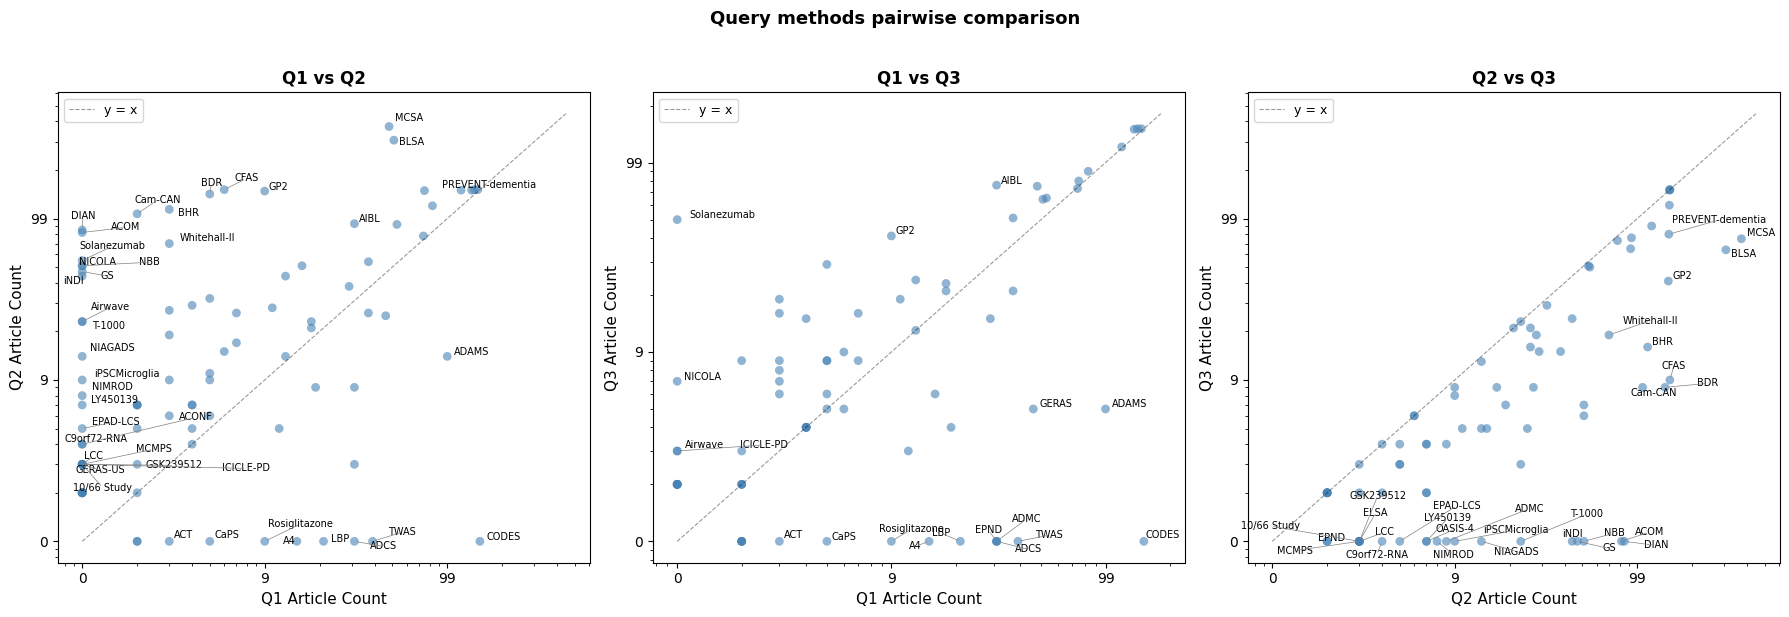

In [5]:
import matplotlib.ticker as ticker
import numpy as np
from adjustText import adjust_text

pairs = [
    ("Q1 Capped 150", "Q2 Capped 150"),
    ("Q1 Capped 150", "Q3 Capped 150"),
    ("Q2 Capped 150", "Q3 Capped 150"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (lbl_x, lbl_y) in zip(axes, pairs):
    x_counts = datasets[lbl_x]["Abbreviation"].value_counts()
    y_counts = datasets[lbl_y]["Abbreviation"].value_counts()

    all_abbrevs = sorted(set(x_counts.index) | set(y_counts.index))
    x = np.array([x_counts.get(a, 0) for a in all_abbrevs])
    y = np.array([y_counts.get(a, 0) for a in all_abbrevs])

    x_plot = x + 1
    y_plot = y + 1

    ax.scatter(x_plot, y_plot, alpha=0.6, color="steelblue", edgecolors="none", s=40)

    lim = max(x_plot.max(), y_plot.max()) * 1.2
    ax.plot([1, lim], [1, lim], "k--", linewidth=0.8, alpha=0.4, label="y = x")

    ax.set_xscale("log")
    ax.set_yscale("log")

    def fmt(val, _, offset=1): return str(int(val - offset))
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(fmt))
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(fmt))

    short = {"Q1 Capped 150": "Q1", "Q2 Capped 150": "Q2", "Q3 Capped 150": "Q3"}
    ax.set_xlabel(f"{short[lbl_x]} Article Count", fontsize=11)
    ax.set_ylabel(f"{short[lbl_y]} Article Count", fontsize=11)
    ax.set_title(f"{short[lbl_x]} vs {short[lbl_y]}", fontsize=12, fontweight="bold")
    ax.legend(fontsize=9)

    diff = np.abs(y - x)
    threshold = np.percentile(diff[diff > 0], 85) if (diff > 0).any() else 0
    texts = []
    for i, abbrev in enumerate(all_abbrevs):
        is_top_diverger = diff[i] >= threshold and (x[i] > 0 or y[i] > 0)
        is_one_zero = (y[i] == 0 and x[i] > 1) or (x[i] == 0 and y[i] > 1)
        if is_top_diverger or is_one_zero:
            texts.append(ax.text(x_plot[i], y_plot[i], abbrev, fontsize=7))

    adjust_text(texts, ax=ax,
                arrowprops=dict(arrowstyle="-", color="gray", lw=0.5),
                expand_points=(1.5, 1.5), force_text=(0.5, 0.5))

plt.suptitle("Query methods pairwise comparison", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()
